In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load Bruins dataset
bruins = pd.read_csv("BostonBruins.csv")

# Preview data
bruins.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.370653e+09,963,i.imgur.com,1fwf1z,Which bear is best? BRUINS!!,bowski477,1204,241,39,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://c.thumbs.redditmedia.com/jibAEayydtpAYJ...,t5_2rmt9,False,NaN,NaN,False,t3_1fwf1z,http://i.imgur.com/Qy1kmIo.jpg,NaN
1,1.370526e+09,861,i.imgur.com,1fsf5b,Gregory Campbell: A Goddamn Superhero.,eDgEIN708,1043,182,58,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://d.thumbs.redditmedia.com/TyCvGrEVoVHl7h...,t5_2rmt9,False,NaN,NaN,False,t3_1fsf5b,http://i.imgur.com/LvAYxty.jpg,NaN
2,1.370350e+09,399,i.minus.com,1fnchy,Marchand exchanges words with Cooke then skate...,bears249,439,40,49,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://a.thumbs.redditmedia.com/uruI22V7tfQL-u...,t5_2rmt9,False,NaN,17third,False,t3_1fnchy,http://i.minus.com/ibvOeOLogSZJ3Y.gif,NaN
3,1.371483e+09,367,qkme.me,1giqe5,I speak for most of New England,wallybinbaz,454,87,50,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://a.thumbs.redditmedia.com/HsZhOCBlMjSZ-R...,t5_2rmt9,False,NaN,NaN,False,t3_1giqe5,http://qkme.me/3uvudh,NaN
4,1.370660e+09,339,wac.9ebf.edgecastcdn.net,1fwm86,SWEEP.GIF,bowski477,397,58,13,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://a.thumbs.redditmedia.com/iiKAq1E8wYD_K_...,t5_2rmt9,False,NaN,NaN,False,t3_1fwm86,http://wac.9ebf.edgecastcdn.net/809EBF/ec-orig...,NaN


In [3]:
bruins.info()

bruins.describe()

bruins.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  978 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                191 non-null    str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      22
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   809
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class     634
is_self                      0
name                         0
url                          0
distinguished              993
dtype: int64

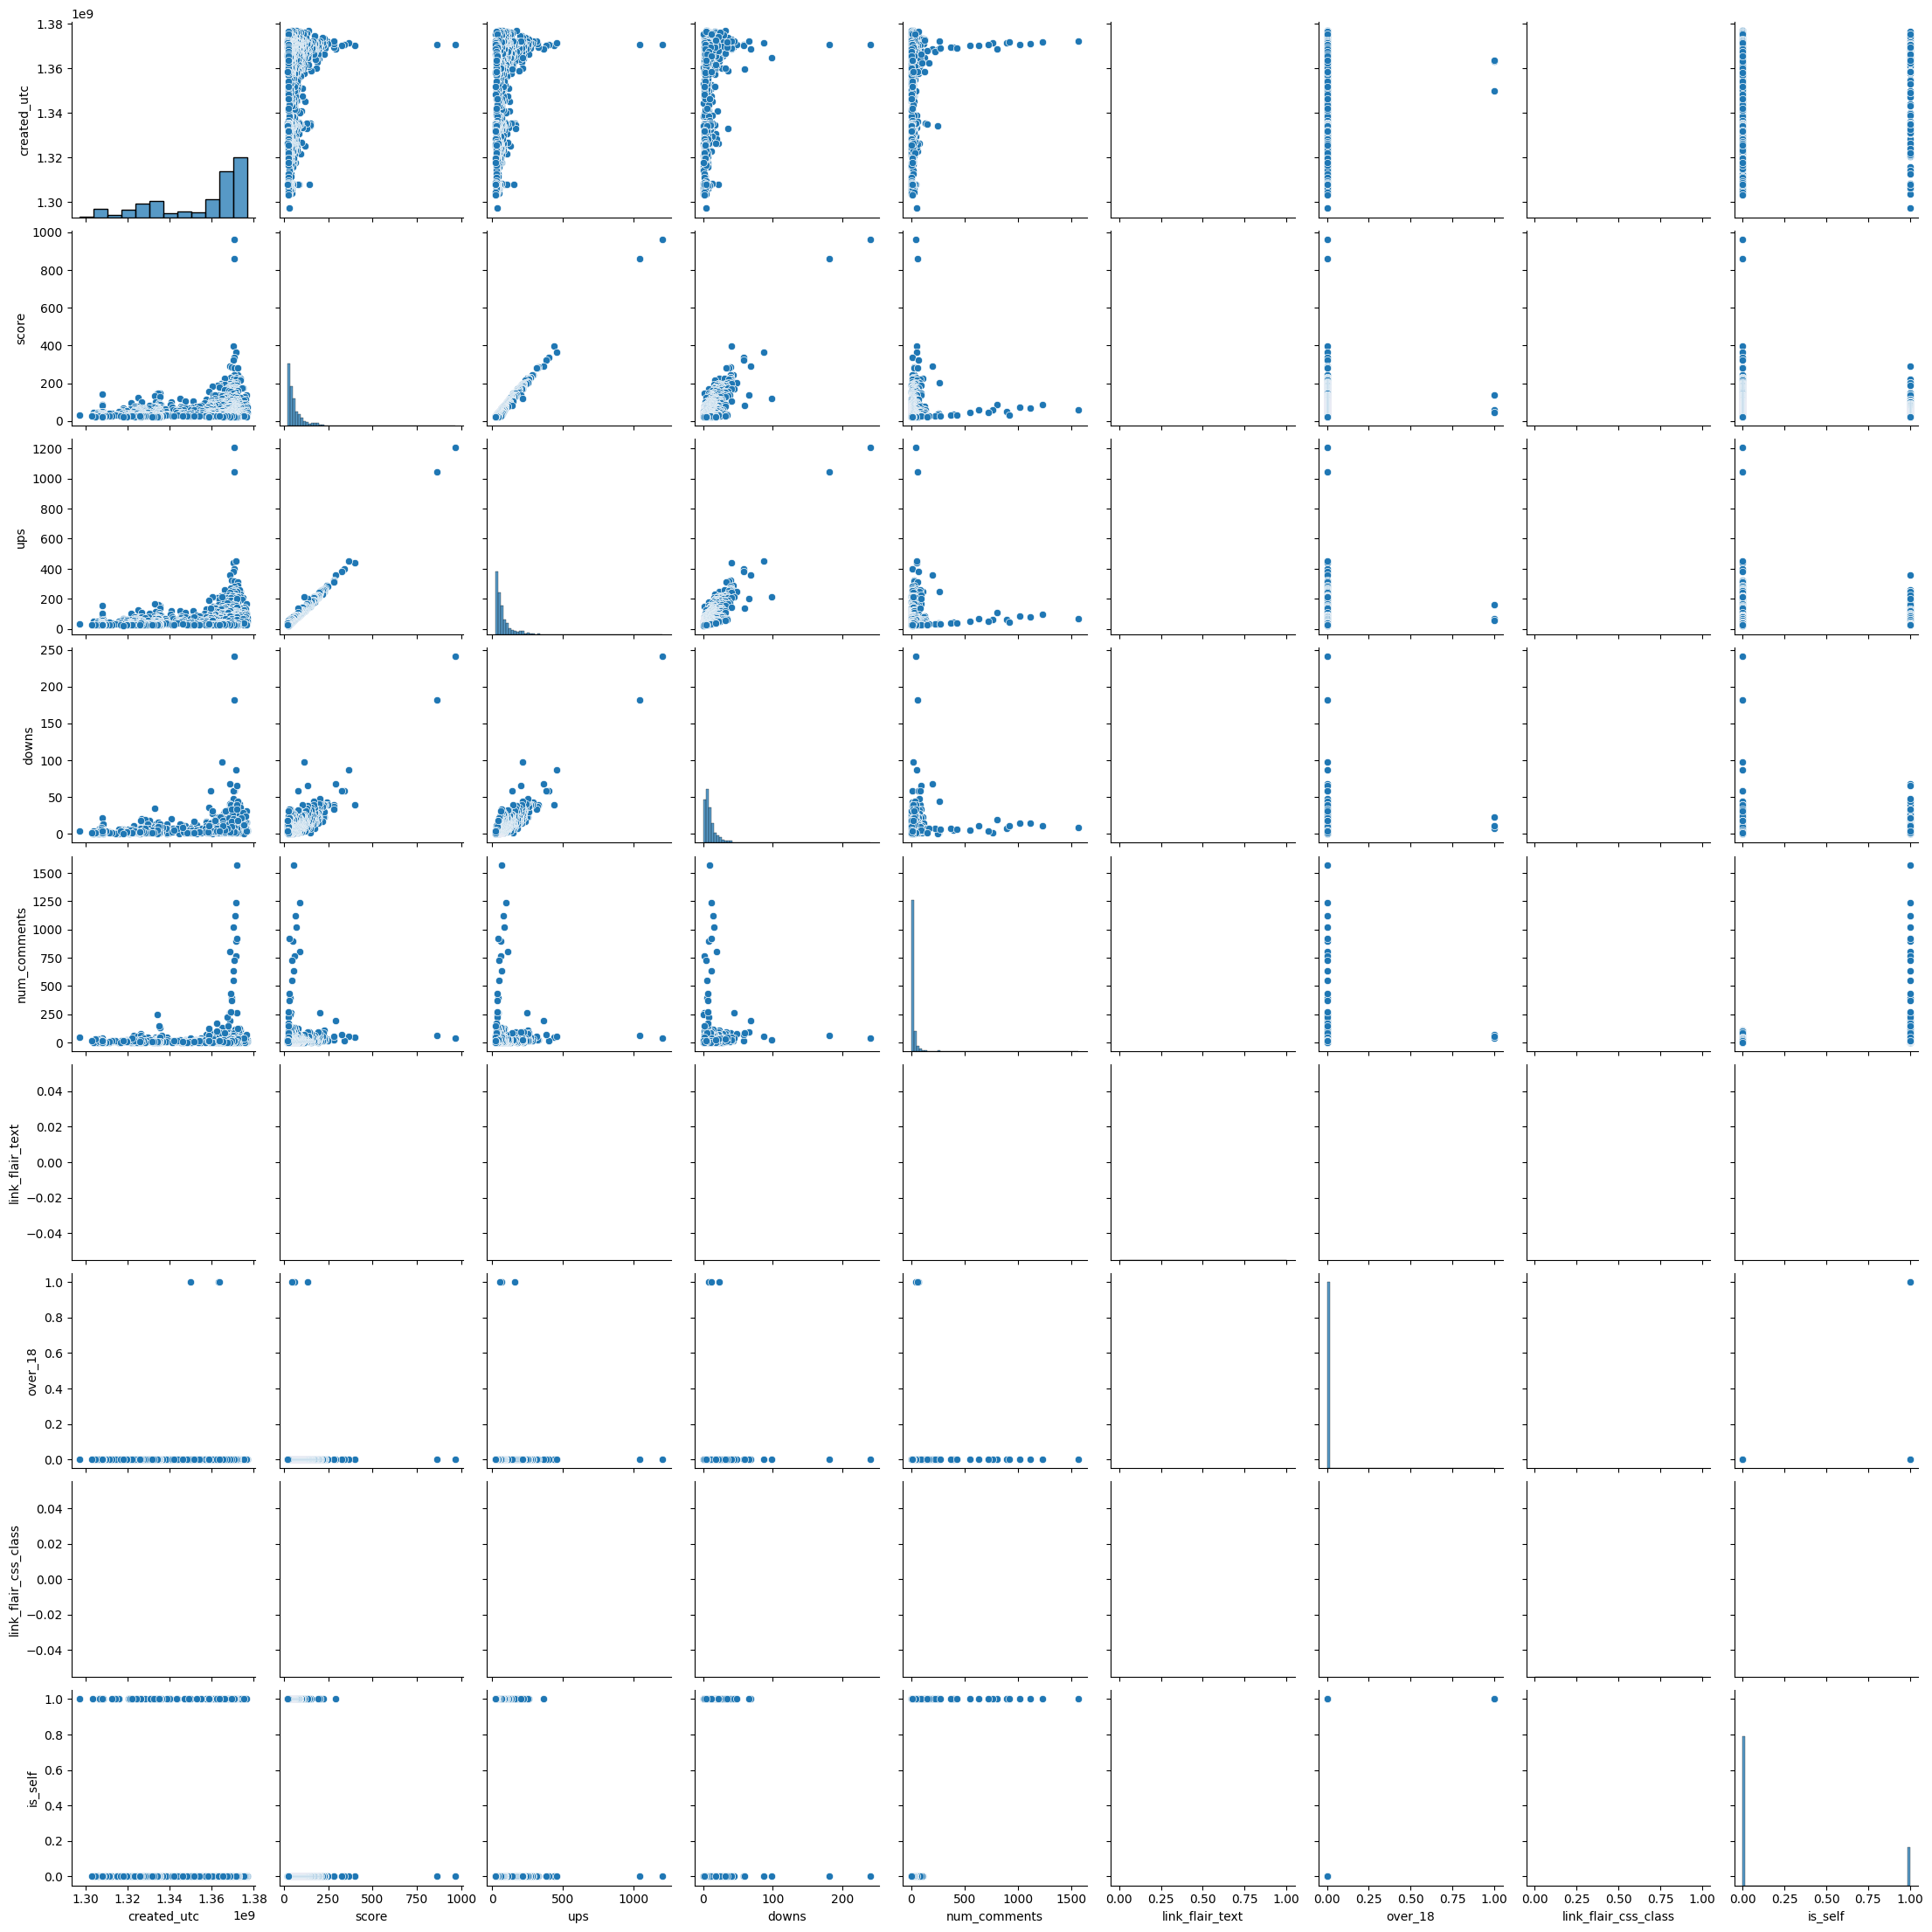

In [4]:
sns.pairplot(bruins)
plt.show()

In [11]:
print(df.dtypes)

created_utc               float64
score                       int64
domain                        str
id                            str
title                         str
author                        str
ups                         int64
downs                       int64
num_comments                int64
permalink                     str
selftext                      str
link_flair_text           float64
over_18                      bool
thumbnail                     str
subreddit_id                  str
edited                        str
link_flair_css_class      float64
author_flair_css_class        str
is_self                      bool
name                          str
url                           str
distinguished                 str
dtype: object


In [12]:
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.370653e+09,963,i.imgur.com,1fwf1z,Which bear is best? BRUINS!!,bowski477,1204,241,39,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://c.thumbs.redditmedia.com/jibAEayydtpAYJ...,t5_2rmt9,False,NaN,NaN,False,t3_1fwf1z,http://i.imgur.com/Qy1kmIo.jpg,NaN
1,1.370526e+09,861,i.imgur.com,1fsf5b,Gregory Campbell: A Goddamn Superhero.,eDgEIN708,1043,182,58,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://d.thumbs.redditmedia.com/TyCvGrEVoVHl7h...,t5_2rmt9,False,NaN,NaN,False,t3_1fsf5b,http://i.imgur.com/LvAYxty.jpg,NaN
2,1.370350e+09,399,i.minus.com,1fnchy,Marchand exchanges words with Cooke then skate...,bears249,439,40,49,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://a.thumbs.redditmedia.com/uruI22V7tfQL-u...,t5_2rmt9,False,NaN,17third,False,t3_1fnchy,http://i.minus.com/ibvOeOLogSZJ3Y.gif,NaN
3,1.371483e+09,367,qkme.me,1giqe5,I speak for most of New England,wallybinbaz,454,87,50,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://a.thumbs.redditmedia.com/HsZhOCBlMjSZ-R...,t5_2rmt9,False,NaN,NaN,False,t3_1giqe5,http://qkme.me/3uvudh,NaN
4,1.370660e+09,339,wac.9ebf.edgecastcdn.net,1fwm86,SWEEP.GIF,bowski477,397,58,13,http://www.reddit.com/r/BostonBruins/comments/...,NaN,NaN,False,http://a.thumbs.redditmedia.com/iiKAq1E8wYD_K_...,t5_2rmt9,False,NaN,NaN,False,t3_1fwm86,http://wac.9ebf.edgecastcdn.net/809EBF/ec-orig...,NaN


In [19]:
X = df.select_dtypes(include=['int64','float64'])

In [22]:
bruins.columns

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')

In [24]:
for col in bruins.columns:
    print(col)

created_utc
score
domain
id
title
author
ups
downs
num_comments
permalink
selftext
link_flair_text
over_18
thumbnail
subreddit_id
edited
link_flair_css_class
author_flair_css_class
is_self
name
url
distinguished


In [26]:
df.columns

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')

In [29]:
df.columns

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')

In [34]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  978 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                191 non-null    str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# Example training data
X = [
    [48, 18, 270, 220, 100],
    [30, 40, 200, 260, 80],
    [55, 15, 300, 200, 120],
    [35, 35, 210, 240, 90]
]

y = [1, 0, 1, 0]   # 1 = Playoffs, 0 = Miss Playoffs

# TRAIN the model
model.fit(X, y)

# Now predict
new_season = [[50, 20, 280, 210, 110]]

prediction = model.predict(new_season)

if prediction[0] == 1:
    print("Predicted: Playoff Team")
else:
    print("Predicted: Miss Playoffs")

Predicted: Playoff Team
